In [15]:
# First run check (beginner safe)
import sys
import numpy as np
import pandas as pd

print('Python version:', sys.version.split()[0])
print('NumPy version:', np.__version__)
print('pandas version:', pd.__version__)
print('Setup check passed. You can continue.')

Python version: 3.9.6
NumPy version: 2.0.2
pandas version: 2.3.3
Setup check passed. You can continue.


# Beginner Start Here (Weeks 4-5: Churn Predictor)

You are not expected to know machine learning yet. This notebook teaches while you build.

## What is churn?
Churn means a customer stops using a product or service.

## What is the goal?
Predict whether a customer will churn (`1`) or stay (`0`).

## Modules used in this notebook
- `pandas`: table data (`DataFrame`) and CSV loading.
- `numpy`: math and arrays.
- `sklearn`: machine learning models and evaluation tools.
- `matplotlib`/`seaborn`: charts and visual analysis.

## Key terms
- Feature: an input column (for example `tenure`, `monthly_charges`).
- Target/Label: what we are trying to predict (`churn`).
- Train/Test split: train on one part of data, evaluate on unseen part.
- Accuracy/Precision/Recall/F1: performance metrics.
- Confusion matrix: table of correct/incorrect predictions.

## How to work through this notebook
1. Run cells from top to bottom.
2. Read markdown before coding.
3. If an error appears, read the last line first.
4. Change one thing at a time and re-run.

# Weeks 4-5: Customer Churn Predictor

## Overview
Build a complete ML pipeline to predict which customers will churn (leave).

**Learning Goals:**
- Full ML pipeline (data → model → evaluation)
- Classification (predicting categories)
- Model comparison
- Business interpretation

**Time:** 8-12 hours across 2 weeks

**Difficulty:** 🟡 Combine foundations + new concepts

---

## Challenge Summary
12 challenges total, completing a full ML project from data preparation to business insights.

## Challenge 1: Load and Explore Data

**Goal:** Load a customer churn dataset and understand its structure.

**Steps:**
1. Import pandas, numpy, matplotlib, seaborn
2. Load dataset (create synthetic or download from Kaggle)
3. Display shape, columns, data types
4. Show first 5 rows
5. Get basic info about the dataset

**Expected outputs:**
- Dataset shape: 5000+ rows × 10-20 columns
- Target column: 'Churn' (yes/no or 1/0)
- Features: customer demographics, usage, billing info

In [28]:
# Challenge 1: Load and Explore Data

# YOUR CODE HERE
df=pd.read_csv("../../../data/phase1/WA_Fn-UseC_-Telco-Customer-Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [31]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [34]:
df.shape

(7043, 21)

In [35]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [36]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

## Challenge 2: Data Quality Check

**Goal:** Understand data completeness and identify issues.

**Steps:**
1. Check for missing values per column
2. Show data types
3. Get summary statistics
4. Check target variable distribution (class balance)
5. Identify any obvious issues

**Expected outputs:**
- Missing values count (hopefully < 5%)
- Data types: mix of numeric and categorical
- Churn class distribution (% churned vs retained)

In [37]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [39]:
df.dtypes

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

In [40]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [42]:
df.isna().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [43]:
churn_counts = df['Churn'].value_counts()
print(churn_counts)

Churn
No     5174
Yes    1869
Name: count, dtype: int64


In [53]:
total_churned=len(df[df['Churn'] == "Yes"])
total_retained=len(df[df['Churn'] == "No"])
print(f"Total Churned: {total_churned}")
print(f"Total Retained: {total_retained}")

Total Churned: 1869
Total Retained: 5174


In [54]:
percent_churned = (total_churned / (total_churned + total_retained)) * 100
print(f"Percentage Churned: {percent_churned:.2f}%")

percent_retained = (total_retained / (total_churned + total_retained)) * 100
print(f"Percentage Retained: {percent_retained:.2f}%")

Percentage Churned: 26.54%
Percentage Retained: 73.46%


## Challenge 3: Visualize Relationships

**Goal:** Understand which features relate to churn.

**Steps:**
1. Create 3-4 visualizations showing:
   - Feature distributions
   - How features differ between churned/retained customers
   - Relationships with churn target
2. Examples: scatter plots, box plots, histograms
3. Label axes clearly

**Expected insights:**
- Some features are clearly different for churned customers
- Patterns visible in the data

In [58]:
plt.__version__

NameError: name 'plt' is not defined

In [60]:
import matplotlib.pyplot as plt
import seaborn as sns


In [55]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


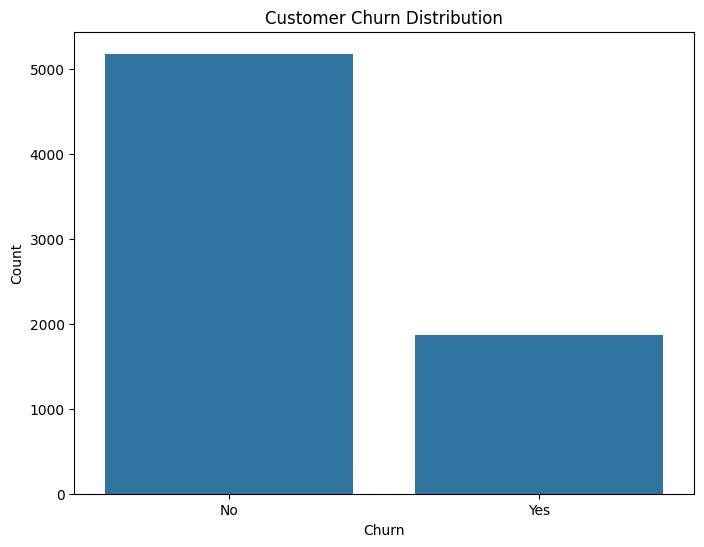

In [61]:
fig, ax = plt.subplots(figsize=(8, 6))
sns.countplot(x='Churn', data=df, ax=ax)
ax.set_title('Customer Churn Distribution')
ax.set_xlabel('Churn')
ax.set_ylabel('Count')
plt.show()

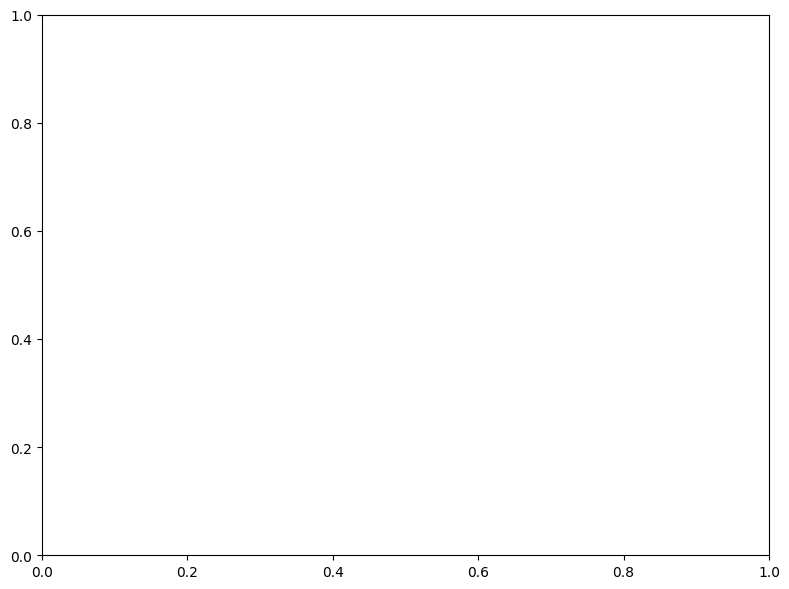

In [63]:
fig, ax = plt.subplots(figsize=(8, 6))


plt.tight_layout()
plt.show()

## Challenge 4: Data Preparation

**Goal:** Prepare data for model training.

**Steps:**
1. Separate features (X) from target (y)
2. Handle missing values (drop or impute)
3. Encode categorical variables (one-hot encoding)
4. Scale numerical features (StandardScaler)
5. Split into train/test (80/20):
   - Train: fit scaler, train model
   - Test: evaluate performance

**Expected outputs:**
- X_train shape: (n, m) where n is ~80% of data
- X_test shape: (n, m) where n is ~20% of data
- Scaled features (mean ~0, std ~1)

In [19]:
# Challenge 4: Data Preparation

# YOUR CODE HERE

## Challenge 5: Train Two Models

**Goal:** Build two competing classification models.

**Steps:**
1. Import LogisticRegression and RandomForestClassifier
2. Train model1 = LogisticRegression(random_state=42)
3. Train model2 = RandomForestClassifier(n_estimators=100, random_state=42)
4. Time each training
5. Make predictions on test set

**Expected:**
- Both models trained successfully
- Predictions are 0 or 1 (binary)
- Random Forest likely slower but potentially more accurate

In [20]:
# Challenge 5: Train Two Models

# YOUR CODE HERE

## Challenge 6: Make Predictions

**Goal:** Generate predictions from both models.

**Steps:**
1. Get class predictions: model.predict(X_test)
2. Get probability predictions: model.predict_proba(X_test)
3. For each model, show:
   - First 10 predictions
   - Corresponding probabilities
   - Actual values
4. Compare predictions between models

**Expected:**
- predictions: array of 0s and 1s
- probabilities: array of values 0.0-1.0
- Some predictions might agree, some differ

In [21]:
# Challenge 6: Make Predictions

# YOUR CODE HERE

## Challenge 7: Evaluate Models

**Goal:** Calculate performance metrics for both models.

**Steps:**
1. Import: accuracy_score, precision_score, recall_score, f1_score
2. For each model, calculate:
   - Accuracy: % correct predictions
   - Precision: % predicted churners who actually churned
   - Recall: % actual churners we caught
   - F1: balance between precision & recall
3. Create comparison table
4. Identify which model performs better

**Expected:**
- All metrics 0.0-1.0
- Usually Random Forest > Logistic Regression
- Metrics might differ (one model good at precision, other at recall)

In [22]:
# Challenge 7: Evaluate Models

# YOUR CODE HERE

## Challenge 8: Confusion Matrix

**Goal:** Understand prediction patterns using confusion matrix.

**Steps:**
1. Import confusion_matrix, classification_report
2. Calculate confusion matrix for best model
3. Visualize as heatmap (seaborn)
4. Interpret:
   - True Negatives (top-left)
   - False Positives (top-right)
   - False Negatives (bottom-left)
   - True Positives (bottom-right)
5. Print classification report

**Expected insight:**
- Model predicts most customer correctly
- Some false positives/negatives are expected

In [23]:
# Challenge 8: Confusion Matrix

# YOUR CODE HERE

## Challenge 9: Feature Importance

**Goal:** Identify which features drive churn predictions.

**Steps:**
1. Extract feature_importances_ from Random Forest
2. Create dataframe with feature names and importances
3. Sort by importance descending
4. Plot top 10 features as horizontal bar chart
5. Print insights: what drives customers to churn?

**Expected:**
- Top features are clearly identified
- Bar chart shows relative importance
- Business insights (e.g., "contract length matters most")

In [24]:
# Challenge 9: Feature Importance

# YOUR CODE HERE

## Challenge 10: Prediction Function

**Goal:** Create reusable function for new predictions.

**Steps:**
1. Create function: predict_churn(customer_data)
2. Function should:
   - Take raw customer features as input
   - Apply same preprocessing (scaling/encoding)
   - Make prediction with best model
   - Return: prediction + probability
3. Test on 3 examples
4. Verify it works correctly

**Expected:**
- Function runs without errors
- Returns prediction (0 or 1) + probability
- Produces reasonable outputs

In [25]:
# Challenge 10: Prediction Function

# YOUR CODE HERE

## Challenge 11: ROC Curves

**Goal:** Compare models using ROC curves.

**Steps:**
1. Import roc_curve, auc, RocCurveDisplay
2. For each model:
   - Calculate ROC curve
   - Calculate AUC score
3. Plot both ROC curves on same graph
4. Include diagonal (random classifier)
5. Add legend with AUC values

**Expected:**
- Both curves above diagonal (better than guessing)
- AUC scores 0.0-1.0
- Better model curve closer to top-left

In [26]:
# Challenge 11: ROC Curves

# YOUR CODE HERE

## Challenge 12: Business Summary Report

**Goal:** Communicate findings to non-technical stakeholders.

**Steps:**
1. Write markdown report with sections:
   - **Problem:** What are we solving? Why?
   - **Data:** How many customers? What features?
   - **Model:** Which model? Why?
   - **Results:** Accuracy, precision, recall (in plain English)
   - **Key Findings:** Top 3-5 churn drivers
   - **Recommendation:** What should the company do?
   - **Limitations:** What we don't know?

2. Use business language (no jargon)
3. Include 1-2 key charts

**Example structure:**
```
# Churn Prediction Report

## Executive Summary
We built a model to predict which customers will leave us.
The model is 85% accurate and can identify 70% of at-risk customers.

## Key Findings
1. Contract type matters most
2. High monthly charges correlate with churn
3. Longer tenure = more loyal

## Recommendations
- Offer discounts to high-value customers
- Improve onboarding for new customers
```

In [27]:
# Challenge 12: Business Summary Report

# YOUR CODE HERE

# Write your report as a string and print it
# Or create a markdown cell with your findings